<a href="https://colab.research.google.com/github/LuisACCosta/ProjetoSuperStarsF1/blob/main/Projeto_estat%C3%ADstica_f%C3%B3rmula_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto de Análise Exploratória de Dados
## Tema: Influência da posição de largada no desempenho final dos pilotos na Fórmula 1 (2010–2020)

### Objetivo
Analisar até que ponto a posição de largada influencia a posição final e a pontuação dos pilotos em corridas de Fórmula 1.

### Perguntas de investigação
1. Existe relação entre posição de largada e posição final?
2. Pilotos que largam mais à frente tendem a pontuar mais?
3. Existem exceções relevantes em que pilotos largam mal e ainda assim terminam bem?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)

In [16]:
from google.colab import files

uploaded = files.upload()

Saving lap_times.csv to lap_times.csv
Saving pit_stops.csv to pit_stops.csv
Saving qualifying.csv to qualifying.csv
Saving races.csv to races.csv
Saving results.csv to results (1).csv
Saving seasons.csv to seasons.csv
Saving sprint_results.csv to sprint_results.csv
Saving status.csv to status.csv
Saving circuits.csv to circuits.csv
Saving constructor_results.csv to constructor_results.csv
Saving constructor_standings.csv to constructor_standings.csv
Saving constructors.csv to constructors.csv
Saving driver_standings.csv to driver_standings.csv
Saving drivers.csv to drivers.csv


In [17]:
results = pd.read_csv("results.csv")
races = pd.read_csv("races.csv")
drivers = pd.read_csv("drivers.csv")

In [18]:
results.head()
races.head()
drivers.head()
print("results:", results.shape)
print("races:", races.shape)
print("drivers:", drivers.shape)

results: (26759, 18)
races: (1125, 18)
drivers: (861, 9)


In [19]:
races_2010_2020 = races[(races["year"] >= 2010) & (races["year"] <= 2020)]
races_2010_2020.head()
df = results.merge(
    races_2010_2020[["raceId", "year", "name"]],
    on="raceId",
    how="inner"
)

df = df.merge(
    drivers[["driverId", "forename", "surname"]],
    on="driverId",
    how="left"
)

df["driver_name"] = df["forename"] + " " + df["surname"]

In [ ]:
df = df[["raceId", "year", "name", "driverId", "driver_name", "grid", "positionOrder", "points"]]
df.head()

,raceId,year,name,driverId,driver_name,grid,positionOrder,points
0,337,2010,Bahrain Grand Prix,4,Fernando Alonso,3,1,25.0
1,337,2010,Bahrain Grand Prix,13,Felipe Massa,2,2,18.0
2,337,2010,Bahrain Grand Prix,1,Lewis Hamilton,4,3,15.0
3,337,2010,Bahrain Grand Prix,20,Sebastian Vettel,1,4,12.0
4,337,2010,Bahrain Grand Prix,3,Nico Rosberg,5,5,10.0


In [ ]:
df.info()
df.isnull().sum()
df = df.dropna(subset=["grid", "positionOrder", "points"])
df["grid"] = pd.to_numeric(df["grid"], errors="coerce")
df["positionOrder"] = pd.to_numeric(df["positionOrder"], errors="coerce")
df["points"] = pd.to_numeric(df["points"], errors="coerce")
df = df.dropna(subset=["grid", "positionOrder", "points"])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4637 entries, 0 to 4636
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   raceId         4637 non-null   int64  
 1   year           4637 non-null   int64  
 2   name           4637 non-null   object 
 3   driverId       4637 non-null   int64  
 4   driver_name    4637 non-null   object 
 5   grid           4637 non-null   int64  
 6   positionOrder  4637 non-null   int64  
 7   points         4637 non-null   float64
dtypes: float64(1), int64(5), object(2)
memory usage: 289.9+ KB


In [ ]:
print("Informações gerais da base:")
df.info()

print("\nValores nulos por coluna:")
print(df.isnull().sum())

df = df.dropna(subset=["grid", "positionOrder", "points"])

df["grid"] = pd.to_numeric(df["grid"], errors="coerce")
df["positionOrder"] = pd.to_numeric(df["positionOrder"], errors="coerce")
df["points"] = pd.to_numeric(df["points"], errors="coerce")

df = df.dropna(subset=["grid", "positionOrder", "points"])

duplicados = df.duplicated().sum()
print("\nQuantidade de registros duplicados:", duplicados)

df = df.drop_duplicates()
print("Shape após remoção de duplicados:", df.shape)

Informações gerais da base:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4637 entries, 0 to 4636
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   raceId              4637 non-null   int64  
 1   year                4637 non-null   int64  
 2   name                4637 non-null   object 
 3   driverId            4637 non-null   int64  
 4   driver_name         4637 non-null   object 
 5   grid                4637 non-null   int64  
 6   positionOrder       4637 non-null   int64  
 7   points              4637 non-null   float64
 8   grid_norm           4637 non-null   float64
 9   positionOrder_norm  4637 non-null   float64
 10  points_norm         4637 non-null   float64
 11  faixa_grid          4637 non-null   object 
dtypes: float64(4), int64(5), object(3)
memory usage: 434.8+ KB

Valores nulos por coluna:
raceId                0
year                  0
name                  0
driverId        

# Comecando os trabalhos:
## 3. Pré-processamento dos Dados

Antes da análise estatística, foi necessário realizar o tratamento da base de dados. Nesta etapa, foram verificados os tipos das variáveis, a presença de valores nulos e a existência de registros duplicados.

Em seguida, as colunas principais da análise (`grid`, `positionOrder` e `points`) foram convertidas para formato numérico, e registros com valores ausentes nessas variáveis foram removidos. Também foi feita a verificação de duplicidade para garantir maior consistência dos resultados.

### Interpretação do pré-processamento

A etapa de pré-processamento permitiu verificar a estrutura da base e confirmar que as variáveis principais estavam adequadas para a análise.

Na base final utilizada, não foram encontrados valores nulos nas colunas analisadas, nem registros duplicados. Além disso, as variáveis principais foram convertidas para formato numérico, garantindo consistência para a aplicação das métricas estatísticas.

Assim, a base mostrou-se limpa e apropriada para a realização da análise exploratória.

## 4. Análise Estatística e Exploratória

Nesta etapa, serão analisadas as variáveis principais do projeto: posição de largada (`grid`), posição final (`positionOrder`) e pontuação (`points`).

O objetivo é verificar até que ponto a posição de largada influencia o desempenho final dos pilotos nas corridas de Fórmula 1, considerando o recorte entre 2010 e 2020.

In [20]:

df["posicoes_ganhas"] = df["grid"] - df["positionOrder"]

print("=== MEDIDAS DE CENTRALIZAÇÃO ===")

print("\nMÉDIA")
print("Pontos conquistados:", df["points"].mean())
print("Posições ganhas na corrida:", df["posicoes_ganhas"].mean())

print("\nMEDIANA")
print("Pontos conquistados:", df["points"].median())
print("Posições ganhas na corrida:", df["posicoes_ganhas"].median())

print("\nMODA")
print("Pontos conquistados:", df["points"].mode().tolist())
print("Posições ganhas na corrida:", df["posicoes_ganhas"].mode().tolist())

print("\n=== QUARTIS ===")
print("\nPontos:")
print(df["points"].quantile([0.25, 0.50, 0.75]))

print("\nPosições ganhas na corrida:")
print(df["posicoes_ganhas"].quantile([0.25, 0.50, 0.75]))

print("\n=== MEDIDAS DE DISPERSÃO ===")

print("\nPontos")
print("Amplitude:", df["points"].max() - df["points"].min())
print("Variância:", df["points"].var())
print("Desvio padrão:", df["points"].std())

print("\nPosições ganhas na corrida")
print("Amplitude:", df["posicoes_ganhas"].max() - df["posicoes_ganhas"].min())
print("Variância:", df["posicoes_ganhas"].var())
print("Desvio padrão:", df["posicoes_ganhas"].std())


=== MEDIDAS DE CENTRALIZAÇÃO ===

MÉDIA
Pontos conquistados: 4.712529652792754
Posições ganhas na corrida: -0.1367263316799655

MEDIANA
Pontos conquistados: 0.0
Posições ganhas na corrida: 0.0

MODA
Pontos conquistados: [0.0]
Posições ganhas na corrida: [0]

=== QUARTIS ===

Pontos:
0.25    0.0
0.50    0.0
0.75    8.0
Name: points, dtype: float64

Posições ganhas na corrida:
0.25   -2.0
0.50    0.0
0.75    3.0
Name: posicoes_ganhas, dtype: float64

=== MEDIDAS DE DISPERSÃO ===

Pontos
Amplitude: 50.0
Variância: 50.41540164520672
Desvio padrão: 7.100380387360013

Posições ganhas na corrida
Amplitude: 45
Variância: 32.486478754468486
Desvio padrão: 5.699691110443485


### Interpretação das estatísticas descritivas

As estatísticas descritivas mostraram que a média da posição de largada foi de aproximadamente **11,2**, enquanto a média da posição final foi de cerca de **11,35**, indicando comportamento geral semelhante entre largada e resultado final.

A média de pontos foi de aproximadamente **4,71**, mas a mediana foi **0**, mostrando que uma grande parte dos pilotos não pontua nas corridas analisadas.

Os quartis reforçam essa interpretação, já que 50% dos registros possuem pontuação igual a 0 e 75% dos registros chegam até 8 pontos. Isso indica forte concentração de baixas pontuações e destaca ainda mais a vantagem competitiva dos pilotos que largam melhor.

In [27]:
print("=== CORRELAÇÃO ===")

corr_grid_pos = df["grid"].corr(df["positionOrder"])
corr_grid_points = df["grid"].corr(df["points"])

corr_ganhas_points = df["posicoes_ganhas"].corr(df["points"])

print("Correlação entre posição de largada e posição final:", round(corr_grid_pos, 4))
print("Correlação entre posição de largada e pontos:", round(corr_grid_points, 4))
print("Correlação entre posições ganhas na corrida e pontos:", round(corr_ganhas_points, 4))


=== CORRELAÇÃO ===
Correlação entre posição de largada e posição final: 0.5973
Correlação entre posição de largada e pontos: -0.6318
Correlação entre posições ganhas na corrida e pontos: 0.2085


## 5. Correlação entre as Variáveis

A correlação foi calculada para verificar a intensidade da relação entre a posição de largada e o desempenho final dos pilotos.

Os resultados mostraram correlação positiva de aproximadamente **0,60** entre a posição de largada e a posição final, indicando que pilotos que largam em posições piores tendem também a terminar em posições piores.

Além disso, foi observada correlação negativa de aproximadamente **-0,63** entre a posição de largada e os pontos conquistados, o que indica que pilotos que largam mais à frente tendem a conquistar mais pontos.

Esses valores mostram que a posição de largada exerce influência relevante sobre o desempenho final, embora não determine sozinha o resultado da corrida.

In [26]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[["grid_norm", "positionOrder_norm", "points_norm", "posicoes_ganhas_norm"]] = scaler.fit_transform(
    df[["grid", "positionOrder", "points", "posicoes_ganhas"]]
)

df[["grid", "grid_norm", "positionOrder", "positionOrder_norm", "points", "points_norm", "posicoes_ganhas", "posicoes_ganhas_norm"]].head()


,grid,grid_norm,positionOrder,positionOrder_norm,points,points_norm,posicoes_ganhas,posicoes_ganhas_norm
0,3,0.125000,1,0.000000,25.0,0.50,2,0.577778
1,2,0.083333,2,0.043478,18.0,0.36,0,0.533333
2,4,0.166667,3,0.086957,15.0,0.30,1,0.555556
3,1,0.041667,4,0.130435,12.0,0.24,-3,0.466667
4,5,0.208333,5,0.173913,10.0,0.20,0,0.533333


## 6. Normalização dos Dados

Foi aplicada a normalização Min-Max nas principais variáveis numéricas para colocá-las em uma escala comum entre 0 e 1. Esse procedimento facilita comparações entre variáveis com amplitudes diferentes.

## 7. Visualizações Gráficas

Nesta etapa, os gráficos serão utilizados para representar visualmente os padrões identificados nas análises estatísticas. O foco será observar a relação entre posição de largada, posição final e pontuação.

### Interpretação do Gráfico 1

O gráfico de dispersão permite observar a relação entre a posição de largada e a posição final. Caso exista uma tendência crescente, isso indica que pilotos que largam em posições piores também tendem a terminar em posições piores.

Assim, o gráfico ajuda a visualizar se a largada exerce influência relevante sobre o resultado final.

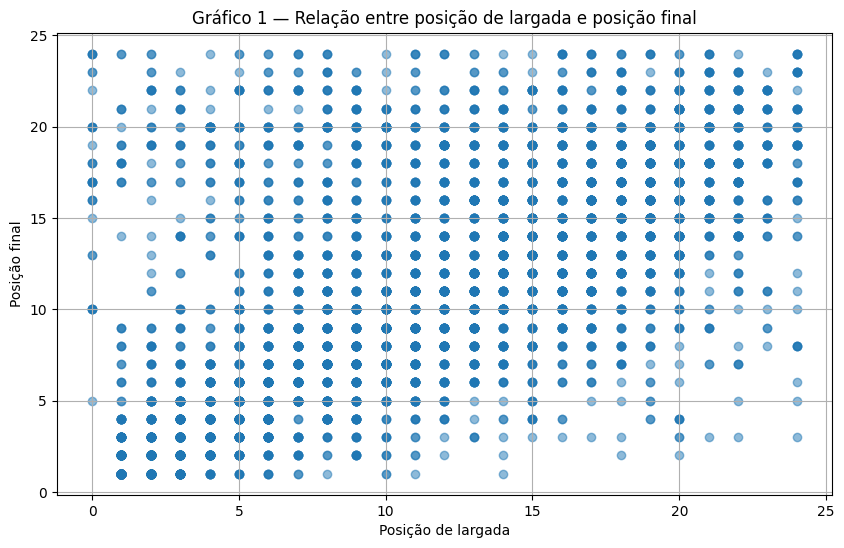

In [23]:
plt.figure(figsize=(10,6))
plt.scatter(df["grid"], df["points"], alpha=0.5)
plt.xlabel("Posição de largada")
plt.ylabel("Pontos")
plt.title("Gráfico 2 — Relação entre posição de largada e pontos conquistados")
plt.grid(True)
plt.show()


### Interpretação do Gráfico 2

Este gráfico mostra a relação entre a posição de largada e os pontos conquistados. A tendência esperada é que pilotos que largam nas primeiras posições obtenham, em média, mais pontos.

Essa visualização complementa a análise anterior ao mostrar não apenas a colocação final, mas também o impacto na pontuação.

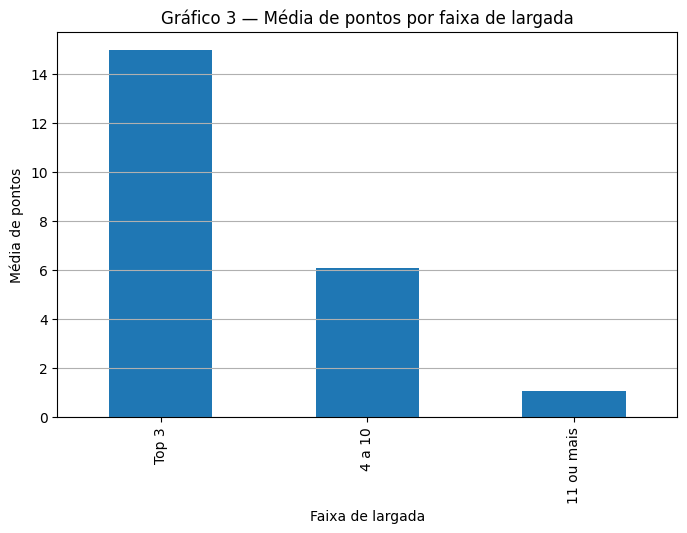

In [ ]:
def faixa_largada(grid):
    if grid <= 3:
        return "Top 3"
    elif grid <= 10:
        return "4 a 10"
    else:
        return "11 ou mais"

df["faixa_grid"] = df["grid"].apply(faixa_largada)

media_pontos = df.groupby("faixa_grid")["points"].mean().reindex(["Top 3", "4 a 10", "11 ou mais"])

plt.figure(figsize=(8,5))
media_pontos.plot(kind="bar")
plt.xlabel("Faixa de largada")
plt.ylabel("Média de pontos")
plt.title("Gráfico 3 — Média de pontos por faixa de largada")
plt.grid(axis="y")
plt.show()

### Interpretação do Gráfico 3

Neste gráfico, os pilotos foram agrupados em três faixas de largada para facilitar a comparação do desempenho médio.

A análise da média de pontos por faixa ajuda a verificar de forma mais clara se largar entre os primeiros colocados realmente traz vantagem competitiva em relação às demais posições do grid.

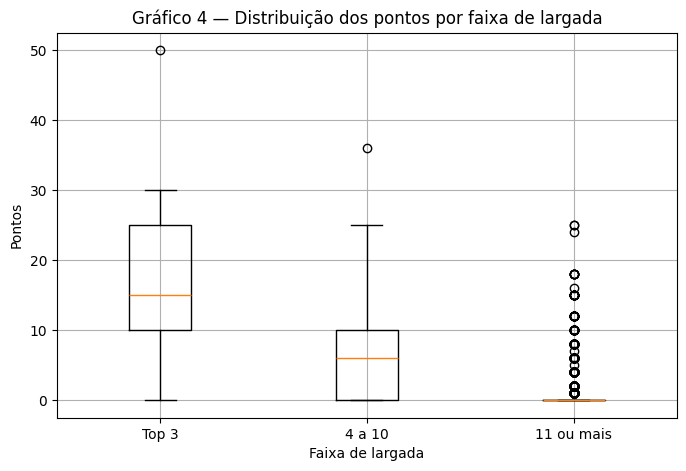

In [ ]:
dados_boxplot = [
    df[df["faixa_grid"] == "Top 3"]["points"],
    df[df["faixa_grid"] == "4 a 10"]["points"],
    df[df["faixa_grid"] == "11 ou mais"]["points"]
]

plt.figure(figsize=(8,5))
plt.boxplot(dados_boxplot, tick_labels=["Top 3", "4 a 10", "11 ou mais"])
plt.xlabel("Faixa de largada")
plt.ylabel("Pontos")
plt.title("Gráfico 4 — Distribuição dos pontos por faixa de largada")
plt.grid(True)
plt.show()

### Interpretação do Gráfico 4

O boxplot mostra a distribuição dos pontos em cada faixa de largada, permitindo observar mediana, dispersão e possíveis valores extremos.

Esse gráfico é importante para verificar não apenas a média, mas também a consistência do desempenho dos pilotos em cada grupo de largada.

In [30]:
excecoes_positivas = df[(df["grid"] >= 10) & (df["positionOrder"] <= 3)]
excecoes_negativas = df[(df["grid"] <= 3) & (df["positionOrder"] > 10)]

print("Exceções positivas:")
display(excecoes_positivas[["year", "name", "driver_name", "grid", "positionOrder", "points"]].head(200))

print("Exceções negativas:")
display(excecoes_negativas[["year", "name", "driver_name", "grid", "positionOrder", "points"]].head(10))



Total de registros: 4637
Exceções positivas: 33
Exceções negativas: 98


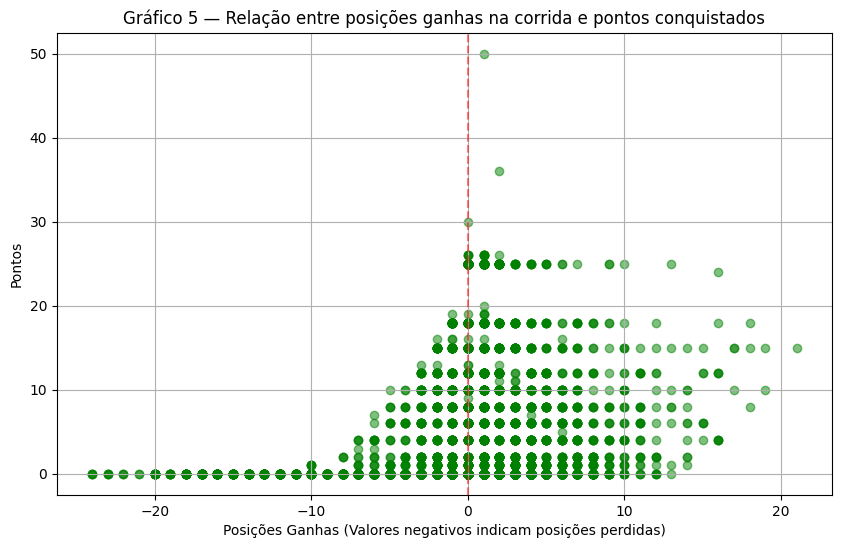

In [24]:
plt.figure(figsize=(10,6)) # Usando uma cor diferente (verde) para destacar a nova métrica
plt.scatter(df["posicoes_ganhas"], df["points"], alpha=0.5, color="green")
plt.xlabel("Posições Ganhas (Valores negativos indicam posições perdidas)")
plt.ylabel("Pontos")
plt.title("Gráfico 5 — Relação entre posições ganhas na corrida e pontos conquistados")
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5) # Linha no zero para facilitar a visualização
plt.grid(True)
plt.show()

### Interpretação dos casos de exceção

Os exemplos apresentados confirmam que a posição de largada tem influência importante, mas não absoluta. Há casos em que pilotos largaram em posições distantes e ainda assim terminaram entre os primeiros, assim como situações em que pilotos largaram entre os primeiros colocados e terminaram muito abaixo do esperado.

Esses casos reforçam que fatores como estratégia, acidentes, ritmo de corrida e abandonos também afetam o resultado final.

## 8. Casos de Exceção

Além da tendência geral observada, também foram analisados casos em que pilotos largaram em posições ruins e terminaram entre os primeiros colocados, bem como situações contrárias.

Esses casos são importantes porque mostram que a posição de largada é uma variável relevante, mas não é capaz de determinar sozinha o resultado final de uma corrida.

## 9. Conclusão

A análise exploratória indicou que a posição de largada influencia o desempenho final dos pilotos nas corridas de Fórmula 1.

Os resultados estatísticos mostraram correlação moderada entre a posição de largada e a posição final (**0,5973**), além de correlação moderada negativa entre a posição de largada e os pontos conquistados (**-0,6318**). Isso indica que pilotos que largam nas primeiras posições tendem, em média, a terminar melhor e conquistar mais pontos.

Os gráficos reforçaram essa tendência, especialmente na comparação por faixas de largada, em que os pilotos do **Top 3** apresentaram pontuação média muito superior aos demais grupos.

No entanto, a análise das exceções mostrou que a largada não é o único fator determinante, já que estratégia, acidentes, abandonos e ritmo de corrida também influenciam os resultados.

Dessa forma, conclui-se que a posição de largada representa uma vantagem importante no desempenho final dos pilotos, mas não garante sozinha o resultado da corrida.